In [8]:
import os
import sys
import warnings

import IPython
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

warnings.filterwarnings("ignore")


In [9]:
_base = os.getcwd()
_project_root = (
    os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
)
ALL_EMOTIONS_CSV = os.path.normpath(
    os.path.join(_project_root, "dataset", "all_emotions.csv")
)

print("CSV path:", ALL_EMOTIONS_CSV)
print("Exists:", os.path.isfile(ALL_EMOTIONS_CSV))

RANDOM_STATE = 42
TEST_SIZE = 0.2
OPTUNA_TRIALS = 60
CV_SPLITS = 5


CSV path: d:\UserData\Downloads\dataset\Emotion-Detecting\dataset\all_emotions.csv
Exists: True


In [10]:
df = pd.read_csv(ALL_EMOTIONS_CSV)
print("Shape:", df.shape)

# Target column in CSV is lowercase 'label' (RF.md names it Label)
TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

print("\n--- Null counts (top 15) ---")
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0].head(15) if nulls.max() > 0 else "No nulls")

print("\n--- Duplicated rows ---", df.duplicated().sum())

print("\n--- Label distribution ---")
print(df[TARGET_COL].astype(str).value_counts(dropna=False))


Shape: (57913, 49)

--- Null counts (top 15) ---
F0_mean               3428
MFCC_C2_std           3428
MFCC_C4_std           3428
MFCC_C5_std           3428
MFCC_C6_std           3428
MFCC_C7_std           3428
MFCC_C8_std           3428
MFCC_C9_std           3428
MFCC_C10_std          3428
MFCC_C11_std          3428
MFCC_C12_std          3428
Delta_MFCC_C0_mean    3428
Delta_MFCC_C1_mean    3428
Delta_MFCC_C2_mean    3428
Delta_MFCC_C3_mean    3428
dtype: int64

--- Duplicated rows --- 3427

--- Label distribution ---
label
anger      9315
disgust    9315
fear       9315
happy      9315
sad        9310
neutral    7915
nan        3428
Name: count, dtype: int64


In [11]:
FEATURE_COLS = ["F0_mean", "F0_std", "F0_range", "Energy_ mean", "Energy_ std", "ZCR_mean", "ZCR_std", "Spectral_centroid_mean", "Spectral_centroid_std", "Spectral_flux_mean", "MFCC_C0_mean", "MFCC_C1_mean", "MFCC_C2_mean", "MFCC_C3_mean", "MFCC_C4_mean", "MFCC_C5_mean", "MFCC_C6_mean", "MFCC_C7_mean", "MFCC_C8_mean", "MFCC_C9_mean", "MFCC_C10_mean", "MFCC_C11_mean", "MFCC_C12_mean", "MFCC_C0_std", "MFCC_C1_std", "MFCC_C2_std", "MFCC_C3_std", "MFCC_C4_std", "MFCC_C5_std", "MFCC_C6_std", "MFCC_C7_std", "MFCC_C8_std", "MFCC_C9_std", "MFCC_C10_std", "MFCC_C11_std", "MFCC_C12_std", "Delta_MFCC_C0_mean", "Delta_MFCC_C1_mean", "Delta_MFCC_C2_mean", "Delta_MFCC_C3_mean", "Delta_MFCC_C4_mean", "Delta_MFCC_C5_mean", "Delta_MFCC_C0_std", "Delta_MFCC_C1_std", "Delta_MFCC_C2_std", "Delta_MFCC_C3_std", "Delta_MFCC_C4_std", "Delta_MFCC_C5_std"]

TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

missing_feat = [c for c in FEATURE_COLS if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing feature columns: {missing_feat[:5]} ...")

# Drop rows with invalid target
_df = df.dropna(subset=[TARGET_COL]).copy()
_df = _df[_df[TARGET_COL].astype(str).str.strip().str.lower() != "nan"]

X = _df[FEATURE_COLS].copy()
y_label = _df[TARGET_COL].astype(str).str.strip()

print("X shape:", X.shape)
print("y unique:", sorted(y_label.unique()))


X shape: (54485, 48)
y unique: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [12]:
# NaN / Inf in features -> median imputation (per column), no StandardScaler (RF.md)
X_proc = X.copy()
for c in FEATURE_COLS:
    s = pd.to_numeric(X_proc[c], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    X_proc[c] = s.fillna(med)

rem_nan = X_proc.isna().sum().sum()
rem_inf = np.isinf(X_proc.select_dtypes(include=[np.number]).values).sum()
print("Remaining NaN cells:", int(rem_nan), "| inf:", int(rem_inf))
X = X_proc


Remaining NaN cells: 0 | inf: 0


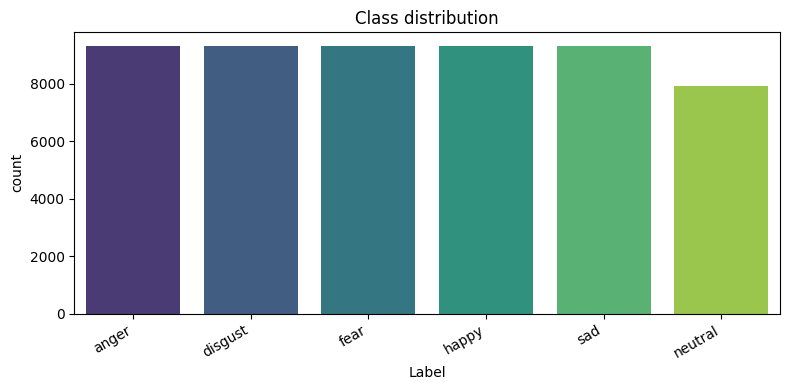

In [13]:
plt.figure(figsize=(8, 4))
order = y_label.value_counts().index.tolist()
sns.countplot(data=pd.DataFrame({"Label": y_label}), x="Label", order=order, palette="viridis")
plt.title("Class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


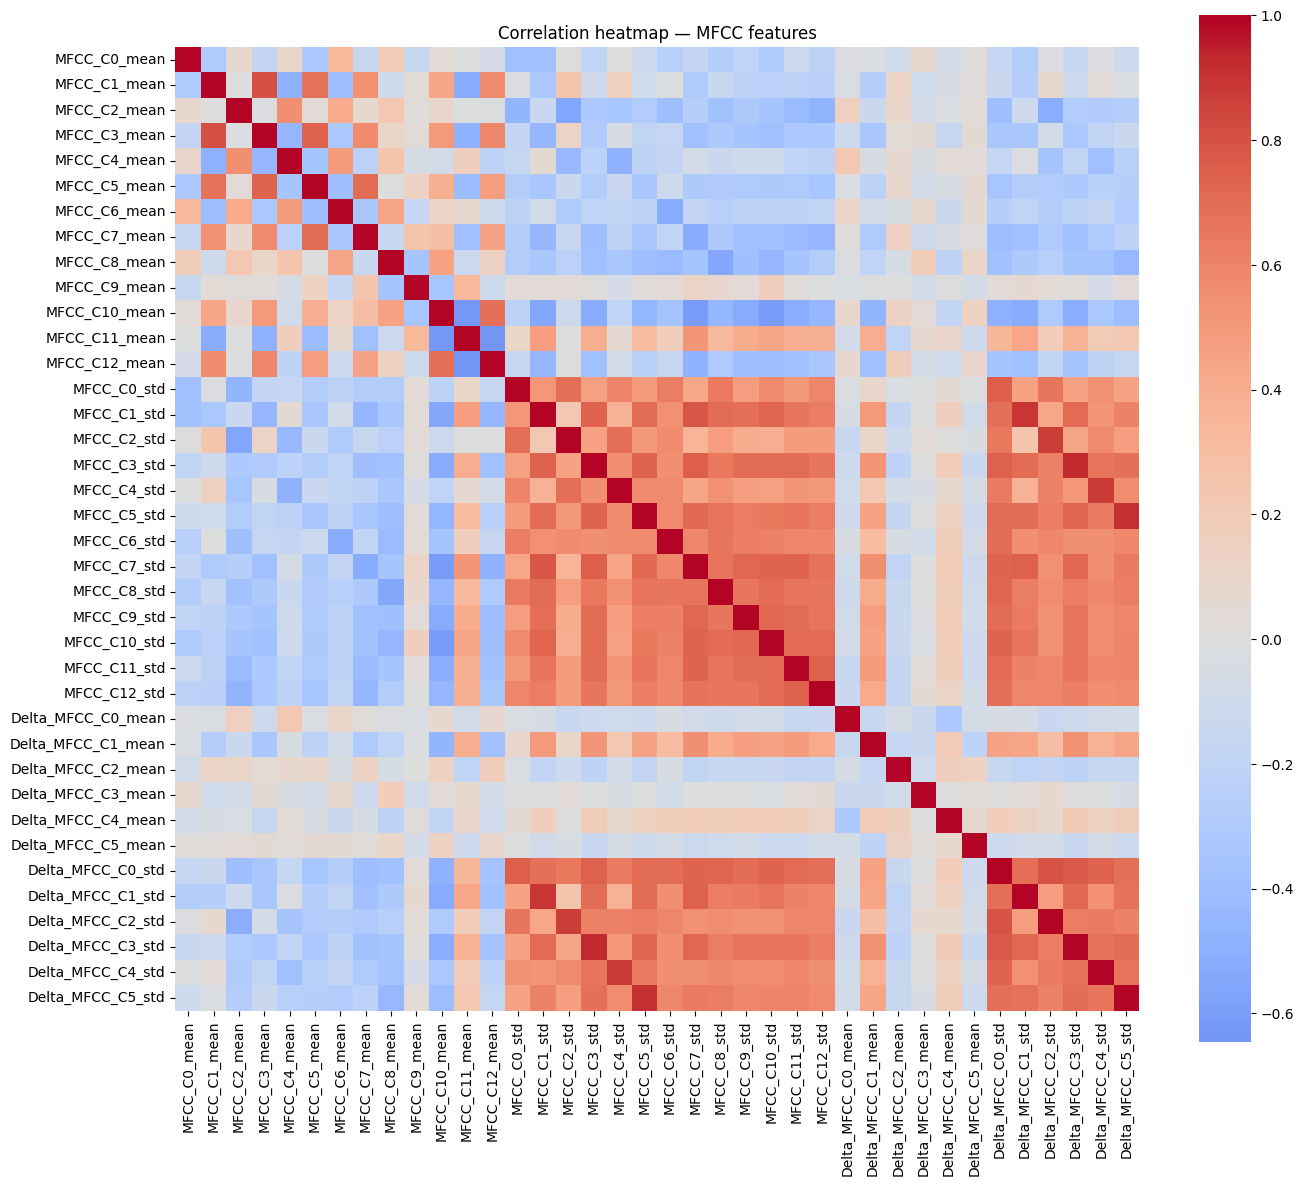

In [14]:
mfcc_cols = [c for c in FEATURE_COLS if "MFCC" in c]
cm = X[mfcc_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap — MFCC features")
plt.tight_layout()
plt.show()


In [15]:
le = LabelEncoder()
y = le.fit_transform(y_label)

print("label_id -> label_name:")
for i, name in enumerate(le.classes_):
    print(f"  {i} -> {name}")

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)


label_id -> label_name:
  0 -> anger
  1 -> disgust
  2 -> fear
  3 -> happy
  4 -> neutral
  5 -> sad
Train: (43588, 48) Test: (10897, 48)


In [16]:
CV_SPLITS = 5
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    # ⚠️ FIX: truyền biến vào bên trong function
    global X_train, y_train, cv

    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 150, 250),
        max_depth=trial.suggest_int("max_depth", 15, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )
    return scores.mean()


In [17]:
OPTUNA_TRIALS = 60
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print("Best value (CV mean F1 weighted):", study.best_value)
print("Best params:", study.best_params)
best_params = study.best_params.copy()

[I 2026-04-27 12:12:26,527] A new study created in memory with name: no-name-0e4bb823-3f9d-401f-9c99-8c1ee3eabf73
Best trial: 0. Best value: 0.803135:   2%|▏         | 1/60 [03:51<3:47:29, 231.35s/it]

[I 2026-04-27 12:16:17,688] Trial 0 finished with value: 0.803134522930919 and parameters: {'n_estimators': 187, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.803134522930919.


Best trial: 0. Best value: 0.803135:   3%|▎         | 2/60 [07:36<3:40:19, 227.92s/it]

[I 2026-04-27 12:20:02,577] Trial 1 finished with value: 0.7897818994987359 and parameters: {'n_estimators': 165, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.803134522930919.


Best trial: 0. Best value: 0.803135:   5%|▌         | 3/60 [11:18<3:33:34, 224.82s/it]

...

[I 2026-04-27 14:49:51,068] Trial 57 finished with value: 0.816176485448217 and parameters: {'n_estimators': 154, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 36 with value: 0.8191838932284623.


Best trial: 36. Best value: 0.819184:  98%|█████████▊| 59/60 [2:39:21<02:03, 123.66s/it]

[I 2026-04-27 14:51:48,253] Trial 58 finished with value: 0.8123191478895924 and parameters: {'n_estimators': 170, 'max_depth': 29, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 36 with value: 0.8191838932284623.


Best trial: 36. Best value: 0.819184: 100%|██████████| 60/60 [2:41:21<00:00, 161.36s/it]

[I 2026-04-27 14:53:48,008] Trial 59 finished with value: 0.8035434982156824 and parameters: {'n_estimators': 183, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 36 with value: 0.8191838932284623.
Best value (CV mean F1 weighted): 0.8191838932284623
Best params: {'n_estimators': 206, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1}


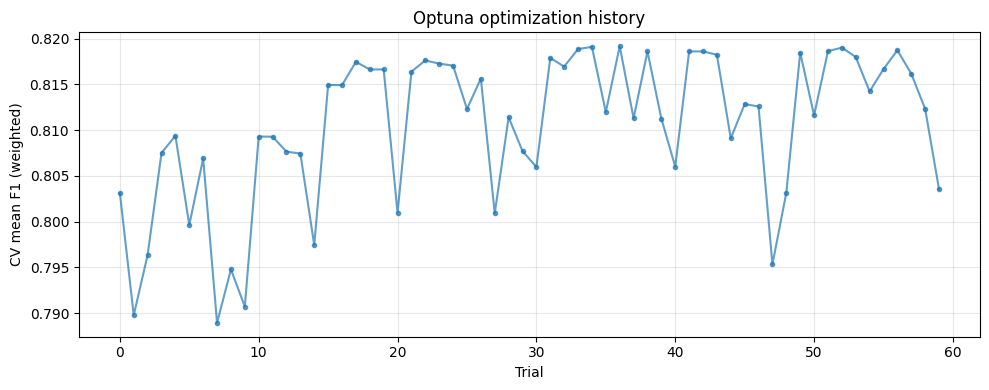

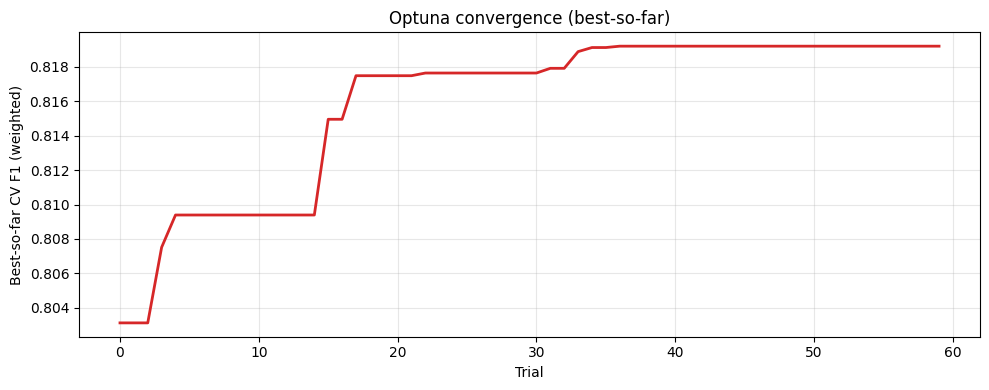

In [23]:
df_hist = study.trials_dataframe()
df_hist = df_hist.sort_values("number")

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"], marker="o", ms=3, alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("CV mean F1 (weighted)")
plt.title("Optuna optimization history")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"].cummax(), color="tab:red", lw=2)
plt.xlabel("Trial")
plt.ylabel("Best-so-far CV F1 (weighted)")
plt.title("Optuna convergence (best-so-far)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
bootstrap_value = best_params.get("bootstrap", True)

final_params = {
    "n_estimators": best_params.get("n_estimators", 200),
    "max_depth": best_params.get("max_depth", None),
    "max_features": best_params.get("max_features", "sqrt"),
    "min_samples_split": best_params.get("min_samples_split", 2),
    "min_samples_leaf": best_params.get("min_samples_leaf", 1),
    "bootstrap": bootstrap_value,
    "class_weight": best_params.get("class_weight", None),
    "oob_score": bootstrap_value,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
# OOB only valid when bootstrap=True (RF.md)
final_params["oob_score"] = bool(best_params.get("bootstrap", True))

rf_final = RandomForestClassifier(**final_params)
rf_final.fit(X_train, y_train)
print("Fitted. oob_score:", getattr(rf_final, "oob_score_", None))


Fitted. oob_score: 0.8223134807745252


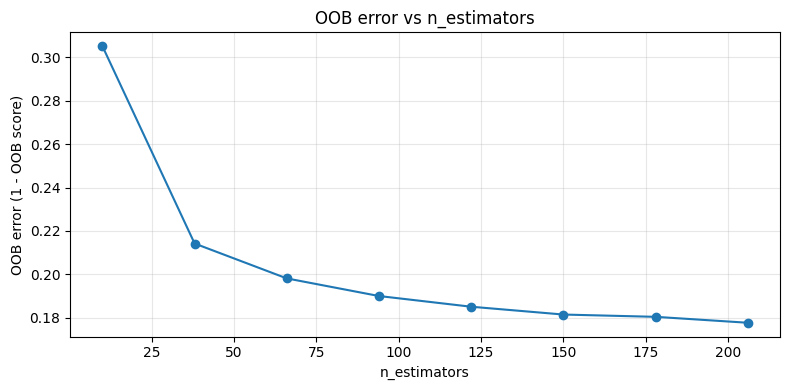

In [26]:
if not best_params.get("bootstrap", True):
    print("bootstrap=False -> OOB score not defined; skip OOB error curve.")
else:
    n_grid = np.linspace(10, int(best_params["n_estimators"]), 8, dtype=int)
    n_grid = np.unique(np.clip(n_grid, 10, None))
    oob_scores = []
    for n_est in n_grid:
        m = RandomForestClassifier(
            n_estimators=int(n_est),
            max_depth=best_params.get("max_depth", None),
            max_features=best_params.get("max_features", "sqrt"),
            min_samples_split=best_params.get("min_samples_split", 2),
            min_samples_leaf=best_params.get("min_samples_leaf", 1),
            bootstrap=True,
            oob_score=True,
            class_weight=best_params.get("class_weight", None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        m.fit(X_train, y_train)
        oob_scores.append(m.oob_score_)

    oob_err = 1.0 - np.array(oob_scores)
    plt.figure(figsize=(8, 4))
    plt.plot(n_grid, oob_err, marker="o")
    plt.xlabel("n_estimators")
    plt.ylabel("OOB error (1 - OOB score)")
    plt.title("OOB error vs n_estimators")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


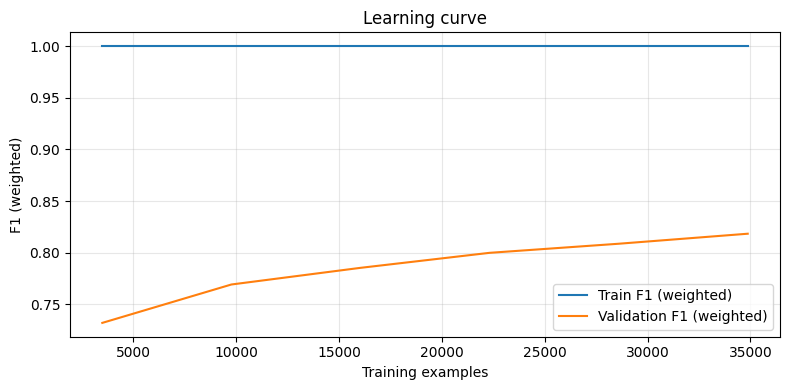

In [27]:
_lc_params = {k: v for k, v in final_params.items() if k != "oob_score"}
train_sizes, train_scores, valid_scores = learning_curve(
    RandomForestClassifier(**_lc_params),
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="f1_weighted",
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, label="Train F1 (weighted)")
plt.plot(train_sizes, valid_mean, label="Validation F1 (weighted)")
plt.xlabel("Training examples")
plt.ylabel("F1 (weighted)")
plt.title("Learning curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
y_pred = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)
print("y_pred shape:", y_pred.shape, "| proba:", y_pred_proba.shape)


y_pred shape: (10897,) | proba: (10897, 6)


In [29]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

f1w = f1_score(y_test, y_pred, average="weighted")
kappa = cohen_kappa_score(y_test, y_pred)
print(f"F1 (weighted): {f1w:.4f}")
print(f"Cohen kappa:   {kappa:.4f}")


              precision    recall  f1-score   support

       anger       0.94      0.89      0.91      1863
     disgust       0.80      0.82      0.81      1863
        fear       0.84      0.80      0.82      1863
       happy       0.77      0.85      0.81      1863
     neutral       0.78      0.80      0.79      1583
         sad       0.87      0.83      0.85      1862

    accuracy                           0.83     10897
   macro avg       0.83      0.83      0.83     10897
weighted avg       0.83      0.83      0.83     10897

F1 (weighted): 0.8320
Cohen kappa:   0.7974


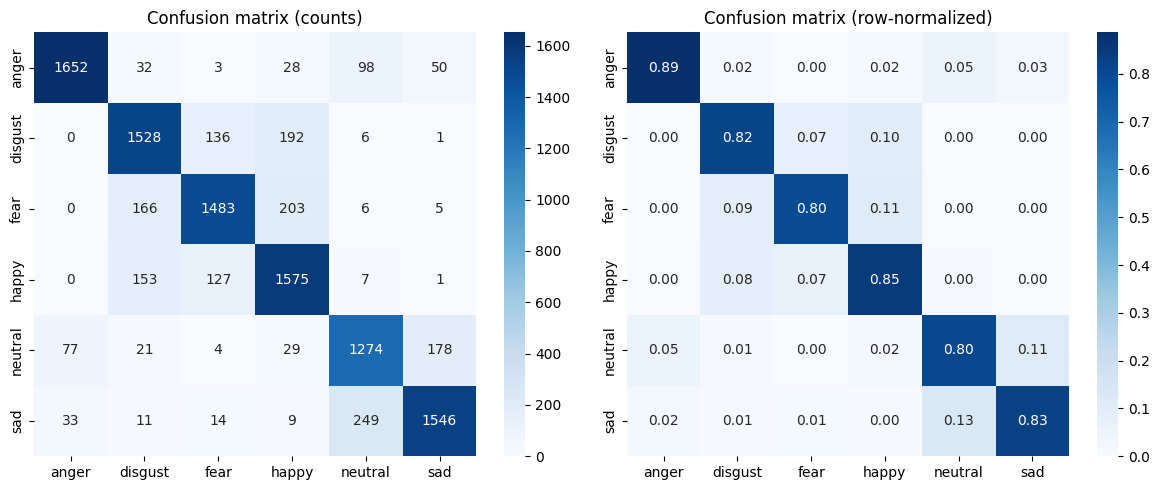

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()


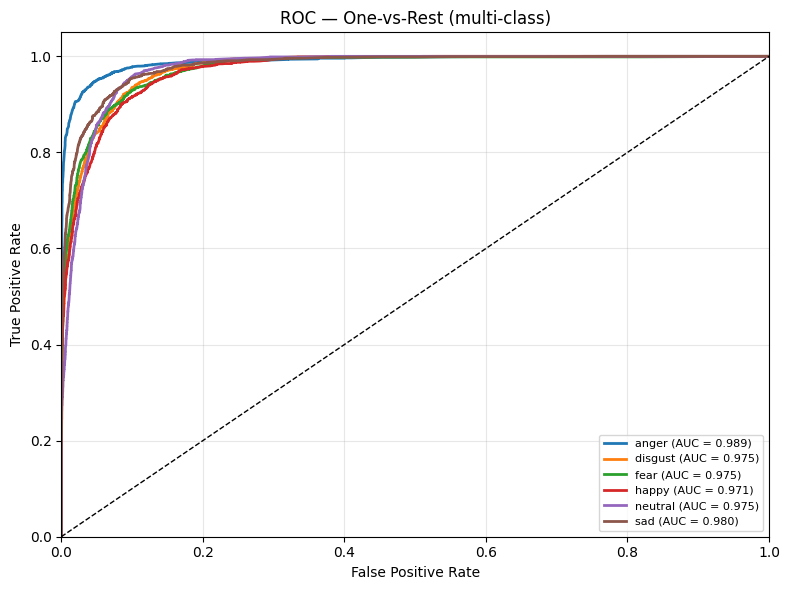

In [31]:
classes = le.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — One-vs-Rest (multi-class)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


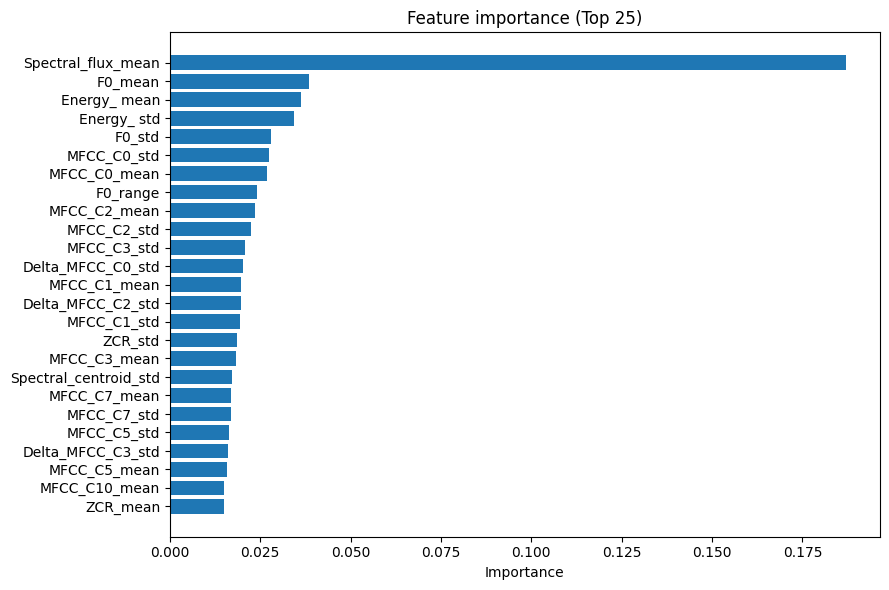

In [32]:
importances = rf_final.feature_importances_
idx = np.argsort(importances)[::-1][:25]
top_feats = [FEATURE_COLS[i] for i in idx]
top_vals = importances[idx]

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_feats)), top_vals[::-1])
plt.yticks(range(len(top_feats)), top_feats[::-1])
plt.xlabel("Importance")
plt.title("Feature importance (Top 25)")
plt.tight_layout()
plt.show()


In [33]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")
micro_f1 = f1_score(y_test, y_pred, average="micro")
kappa = cohen_kappa_score(y_test, y_pred)

summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "f1_weighted",
            "f1_macro",
            "f1_micro",
            "cohen_kappa",
            "optuna_best_cv_f1",
            "test_size",
            "n_train",
            "n_test",
        ],
        "value": [
            acc,
            f1w,
            macro_f1,
            micro_f1,
            kappa,
            study.best_value,
            TEST_SIZE,
            len(y_train),
            len(y_test),
        ],
    }
)
print(summary.to_string(index=False))


           metric        value
         accuracy     0.831238
      f1_weighted     0.831951
         f1_macro     0.830916
         f1_micro     0.831238
      cohen_kappa     0.797384
optuna_best_cv_f1     0.819184
        test_size     0.200000
          n_train 43588.000000
           n_test 10897.000000
